# train.ipynb — Train a gradient boosting model on AAPL stock prices

Saves the learned model to `model.pkl` so `app.py` can load it.

In [ ]:
import yfinance as yf
import joblib
import matplotlib.pyplot as plt
from sklearn.ensemble import GradientBoostingRegressor

## 1. Fetch data

In [12]:
print("Fetching AAPL data from Yahoo Finance ...")
df = yf.Ticker("AAPL").history(period="2y")
print(f"  Loaded {len(df)} trading days.")
df.head()

Fetching AAPL data from Yahoo Finance ...
  Loaded 500 trading days.


,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
2024-05-13 00:00:00-04:00,184.016807,185.664071,183.203093,184.850357,72044800,0.0,0.0
2024-05-14 00:00:00-04:00,186.070904,186.854849,184.860266,185.991516,52393600,0.0,0.0
2024-05-15 00:00:00-04:00,186.467870,189.186832,185.932006,188.263977,70400000,0.0,0.0
2024-05-16 00:00:00-04:00,189.008211,189.633381,188.204430,188.383041,52845200,0.0,0.0
2024-05-17 00:00:00-04:00,188.055574,189.345600,187.728104,188.412811,41282900,0.0,0.0


## 2. Build features

Three features: today's close, today's volume, 7-day moving average.

Target: tomorrow's close — i.e. the Close one row down.

In [13]:
df["MA7"] = df["Close"].rolling(7).mean()
df["Target"] = df["Close"].shift(-1)
df = df.dropna()

X = df[["Close", "Volume", "MA7"]]
y = df["Target"]

print(f"  {len(X)} training examples with {X.shape[1]} features.")
X.head()

  493 training examples with 3 features.


,Close,Volume,MA7
Date,,,
2024-05-21 00:00:00-04:00,190.873810,42309400,188.049905
2024-05-22 00:00:00-04:00,189.434891,34648500,188.704838
2024-05-23 00:00:00-04:00,185.445770,51005900,188.626875
2024-05-24 00:00:00-04:00,188.521942,36327000,188.663727
2024-05-28 00:00:00-04:00,188.531906,52280100,188.684993


## 3. Train the model

In [ ]:
print("Training GradientBoostingRegressor ...")
model = GradientBoostingRegressor(n_estimators=200, max_depth=3, random_state=42)
model.fit(X, y)

## 4. What did the model learn?

In [ ]:
print("Feature importances learned by the model:")
for name, imp in zip(X.columns, model.feature_importances_):
    print(f"  {name:<8} = {imp:.4f}")

print(f"\n  R² on training data: {model.score(X, y):.4f}")

## 5. Visualize the data and predictions

### Price history with 7-day moving average

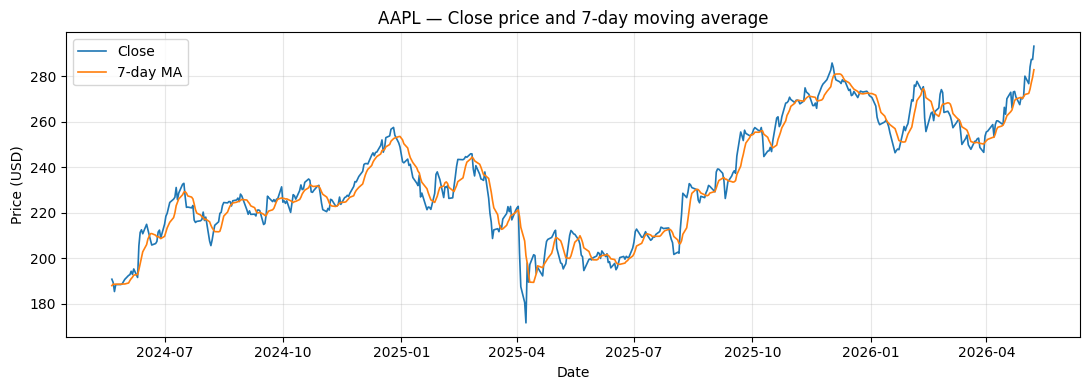

In [16]:
fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(df.index, df["Close"], label="Close", linewidth=1.2)
ax.plot(df.index, df["MA7"], label="7-day MA", linewidth=1.2)
ax.set_title("AAPL — Close price and 7-day moving average")
ax.set_xlabel("Date")
ax.set_ylabel("Price (USD)")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Predicted vs. actual next-day close

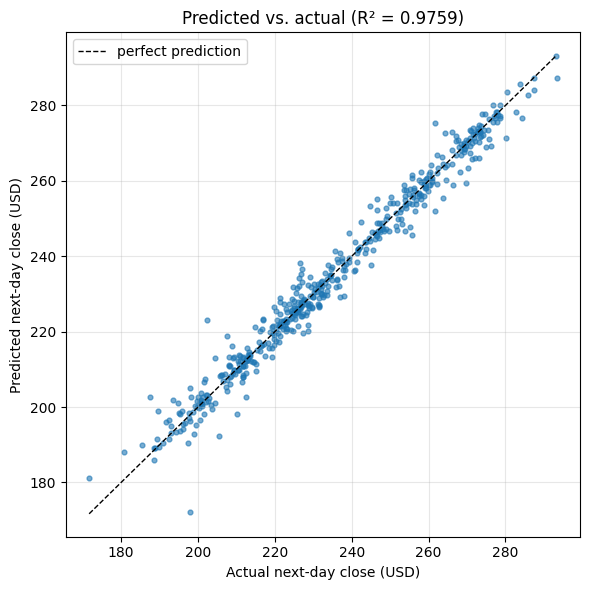

In [17]:
y_pred = model.predict(X)

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(y, y_pred, s=12, alpha=0.6)
lims = [min(y.min(), y_pred.min()), max(y.max(), y_pred.max())]
ax.plot(lims, lims, "k--", linewidth=1, label="perfect prediction")
ax.set_xlabel("Actual next-day close (USD)")
ax.set_ylabel("Predicted next-day close (USD)")
ax.set_title(f"Predicted vs. actual (R² = {model.score(X, y):.4f})")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Residuals over time
Difference between actual and predicted next-day close.

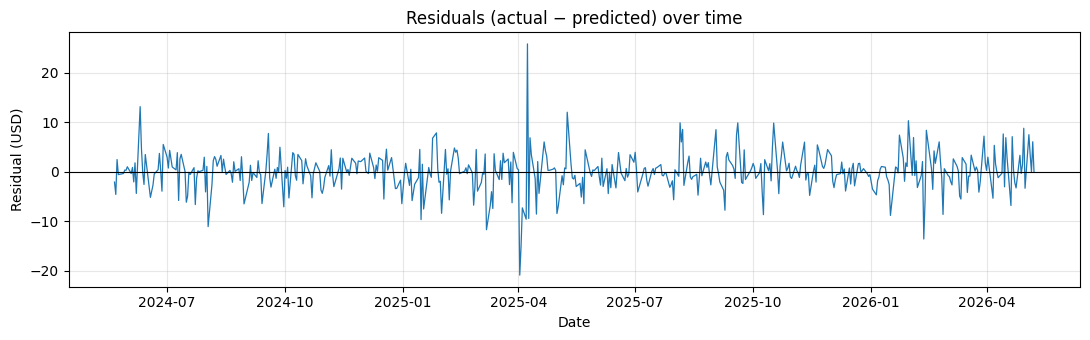

Mean residual:  -0.0000
Std  residual:   3.9257


In [18]:
residuals = y - y_pred

fig, ax = plt.subplots(figsize=(11, 3.5))
ax.plot(df.index, residuals, linewidth=0.9)
ax.axhline(0, color="k", linewidth=0.8)
ax.set_title("Residuals (actual − predicted) over time")
ax.set_xlabel("Date")
ax.set_ylabel("Residual (USD)")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Mean residual: {residuals.mean():>8.4f}")
print(f"Std  residual: {residuals.std():>8.4f}")

## 6. Save the model

In [19]:
joblib.dump(model, "model.pkl")
print("Model saved: model.pkl")
print("  --> Now run 'streamlit run app.py' to use it.")

Model saved: model.pkl
  --> Now run 'streamlit run app.py' to use it.
